In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/customer_churn.csv')

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

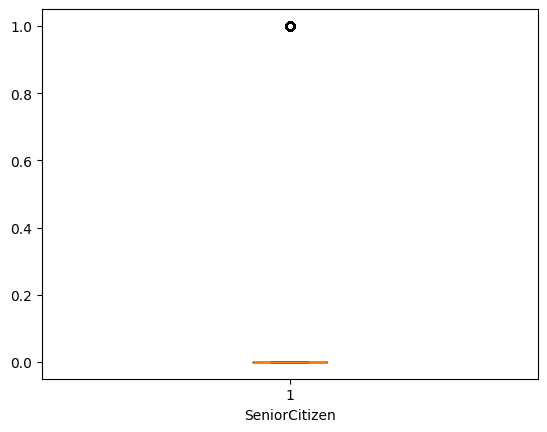

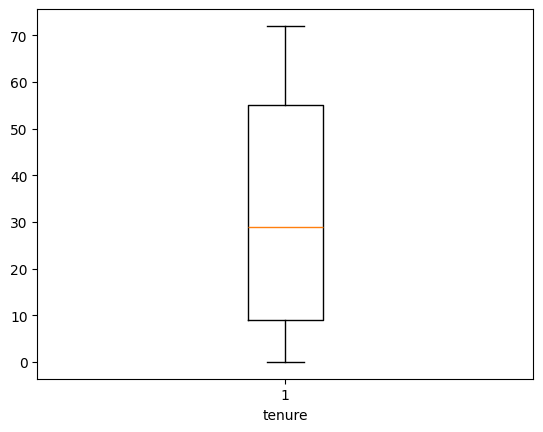

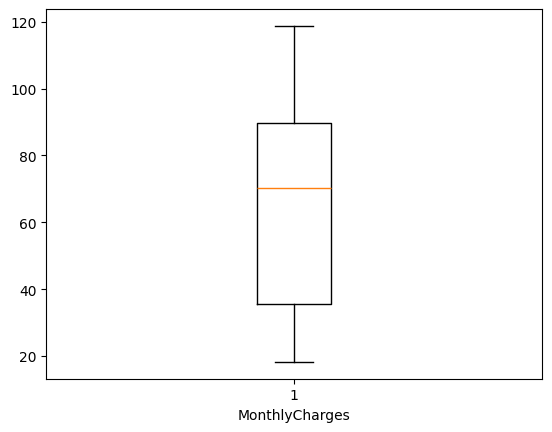

In [ ]:
#Checking for Outliers
for col in df.columns:
  if(df[col].dtype != 'object'):
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
df=df.drop('customerID',axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if (df[col].dtype == 'object')  &  (col !="Churn") :
        df[col]=le.fit_transform(df[col])

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,No
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,No
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,Yes
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,No
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597,No
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698,No
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994,No
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660,Yes


In [ ]:
# Splitting the data for Training and Testing
x = df.drop('Churn', axis = 1)
y = df['Churn']

In [ ]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660


In [ ]:
y

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split( x, y , test_size=0.1 , random_state=0  )

In [ ]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2200,0,0,0,0,19,1,0,0,0,2,0,0,2,0,1,0,2,58.20,87
4627,1,0,0,0,60,1,2,1,2,2,2,2,2,2,1,1,1,116.60,5543
3225,0,0,0,0,13,1,0,0,2,0,0,0,2,2,0,1,2,71.95,6378
2828,1,0,0,0,1,1,0,2,1,1,1,1,1,1,2,0,3,20.45,1615
3768,0,0,1,0,55,1,2,1,0,2,0,0,0,0,0,1,1,77.75,3637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378,1,0,1,0,72,1,0,0,2,2,2,2,2,2,2,0,3,84.45,4935
6920,1,0,0,1,27,1,0,2,1,1,1,1,1,1,2,0,1,19.70,4298
6515,0,0,0,0,29,0,1,0,0,0,0,0,0,0,0,1,1,25.10,5588
2213,0,0,1,1,12,1,2,2,1,1,1,1,1,1,2,0,1,25.25,2382


In [ ]:
# Model Building
from sklearn.ensemble import RandomForestClassifier

model_1 = RandomForestClassifier()

# Train this model 1 by using training data (x_train , y_train)
model_1.fit(x_train , y_train)

# Ask the model to predict churn value for testing data (x_test)
y_pred = model_1.predict(x_test)

# Now use original testing data churn values  (y_test ) to compare predicted churn values
from sklearn.metrics import accuracy_score
print("Accuracy score of this Random Forest model is :", accuracy_score(y_test , y_pred)*100)

Accuracy score of this Random Forest model is : 77.73049645390071


**We are getting 78-79% of Accuracy score with a Basic Random Forest model**

In [ ]:
# Model Building
from sklearn.ensemble import RandomForestClassifier

model_1 = RandomForestClassifier(n_estimators =500)  # n_estimators= To define how many decision tree you want to use inside your random forest model

# Train this model 1 by using training data (x_train , y_train)
model_1.fit(x_train , y_train)

# Ask the model to predict churn value for testing data (x_test)
y_pred = model_1.predict(x_test)

# Now use original testing data churn values  (y_test ) to compare predicted churn values
from sklearn.metrics import accuracy_score
print("Accuracy score of this Random Forest model is :", accuracy_score(y_test , y_pred)*100)

Accuracy score of this Random Forest model is : 79.14893617021276


In [ ]:
n_estimators_data = [5,10,25,50,100,150,200,250,300,500,1000]
for i in n_estimators_data:
  model_1 = RandomForestClassifier(n_estimators = i)  # n_estimators= To define how many decision tree you want to use inside your random forest model
  # Train this model 1 by using training data (x_train , y_train)
  model_1.fit(x_train , y_train)
  # Ask the model to predict churn value for testing data (x_test)
  y_pred = model_1.predict(x_test)
  # Now use original testing data churn values  (y_test ) to compare predicted churn values
  from sklearn.metrics import accuracy_score
  print("Accuracy score of this Random Forest model with DT no:" ,  i  , "is:", accuracy_score(y_test , y_pred)*100)



Accuracy score of this Random Forest model with DT no: 5 is: 76.59574468085107
Accuracy score of this Random Forest model with DT no: 10 is: 75.88652482269504
Accuracy score of this Random Forest model with DT no: 25 is: 77.02127659574468
Accuracy score of this Random Forest model with DT no: 50 is: 78.43971631205675
Accuracy score of this Random Forest model with DT no: 100 is: 79.43262411347519
Accuracy score of this Random Forest model with DT no: 150 is: 79.00709219858156
Accuracy score of this Random Forest model with DT no: 200 is: 79.29078014184398
Accuracy score of this Random Forest model with DT no: 250 is: 79.14893617021276
Accuracy score of this Random Forest model with DT no: 300 is: 78.86524822695036
Accuracy score of this Random Forest model with DT no: 500 is: 79.14893617021276
Accuracy score of this Random Forest model with DT no: 1000 is: 78.86524822695036
